In [24]:
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

In [26]:
df = pd.read_csv('insurance.csv')
df.head

<bound method NDFrame.head of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

(1338, 7)


<Axes: >

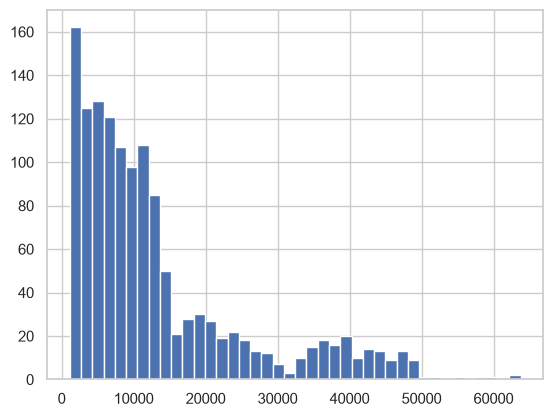

In [27]:
# analyzing the insurance dataset
print(df.shape) # this will show a tuple (number of rows, number of columns)
df.charges.hist(bins=40) # bins is the amount of bars on the graph

<Axes: >

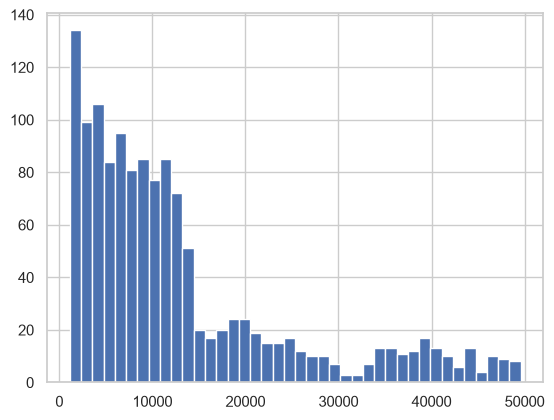

In [28]:
# checking out values greater than 5000 only
df[df.charges > 5000]
# now i just want to take the portion of the data lesser than 50000 as dataset
df = df[df.charges < 50000]
df.charges.hist(bins=40) # visualize the filtered data

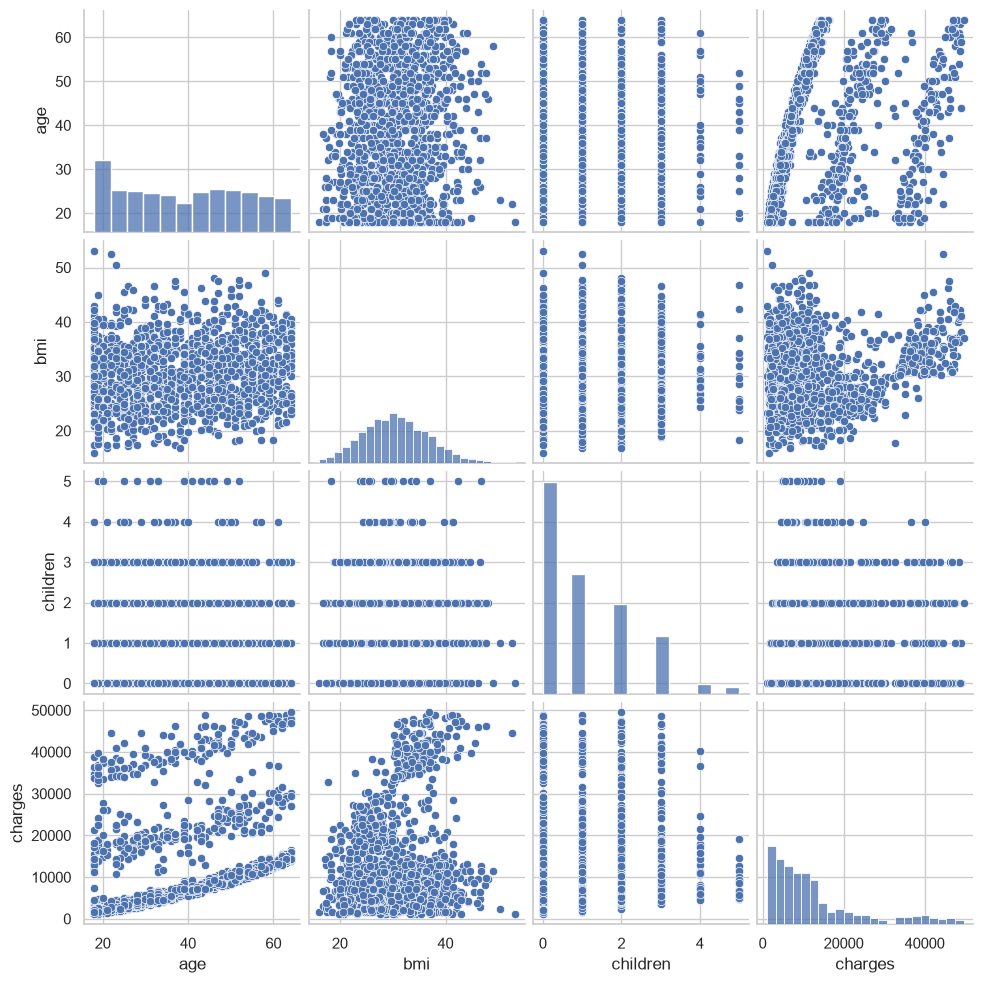

In [29]:
# correlation analysis
import matplotlib.pyplot as plt
sns.pairplot(df, height=2.5)
plt.show()

<Axes: >

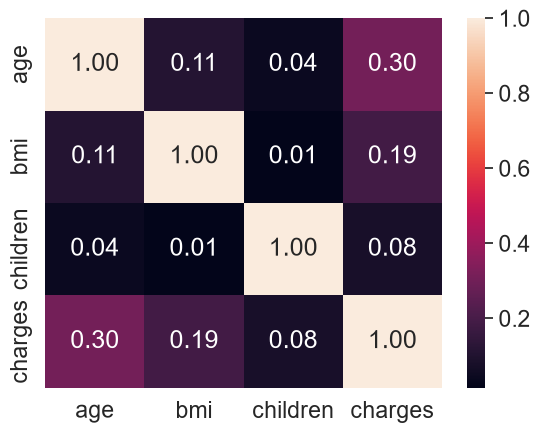

In [30]:
# heat map correlation
import numpy as np
numeric_cols = ['age', 'bmi', 'children', 'charges']
corr_matrix = np.corrcoef(df[numeric_cols].values.T)
sns.set_theme(font_scale=1.5)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", yticklabels=numeric_cols, xticklabels=numeric_cols)

In [31]:
# applying one-hot encoding for categorical variables
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], dtype=int)

In [32]:
# creating the model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_cols = list(set(df.columns) - set(['charges']))
Y_col = ['charges']

X = df[X_cols].values
Y = df[Y_col].values

# splitting the data into training and testing sets
# corpus 80-20
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

ss_x = StandardScaler()
X_train = ss_x.fit_transform(X_train)
X_test = ss_x.fit_transform(X_test)

ss_y = StandardScaler()
Y_train = ss_y.fit_transform(Y_train)
Y_test = ss_y.fit_transform(Y_test)

# creating and training the linear regression model
model = LinearRegression()
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
print(y_pred.shape)

(267, 1)


In [35]:
# evaluating
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)
print(f"Mean Squared Error: {mse.real:.2f}")
print(f"R^2 Score: {r2.real:.2f}")

Mean Squared Error: 0.22
R^2 Score: 0.78


In [36]:
# checking stats
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

model = sm.OLS(Y_train, X_train_sm)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     383.9
Date:                Sun, 13 Sep 2026   Prob (F-statistic):          3.92e-306
Time:                        21:27:56   Log-Likelihood:                -784.25
No. Observations:                1064   AIC:                             1586.
Df Residuals:                    1055   BIC:                             1631.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.197e-16      0.016  -7.69e-15      1.0

C:\Users\Hector\AppData\Local\Temp\ipykernel_6936\146185518.py:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results = model.fit()


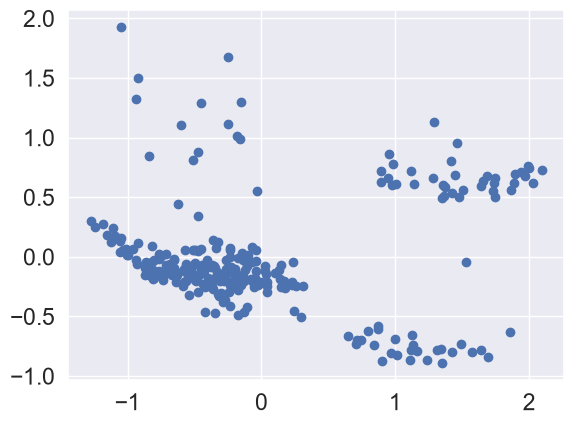

In [37]:
# computing residuals
residuals = np.subtract(Y_test, y_pred)
plt.scatter(y_pred, residuals)
plt.show()

In [40]:
# feature engineering
df_clone = df.copy()
df_clone['age_squared'] = df_clone['age'] ** 2
df_clone['over_weight'] = (df_clone['bmi'] > 30).astype(int)
df_clone['smoker_ow'] = df_clone.over_weight * df_clone['smoker_yes']

In [41]:
# creating new model after feature engineering applied
X_cols = list(set(df_clone.columns) - set(['charges']))
Y_col = ['charges']

X = df_clone[X_cols].values
Y = df_clone[Y_col].values

# splitting the data into training and testing sets
# corpus 80-20
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

ss_x = StandardScaler()
X_train = ss_x.fit_transform(X_train)
X_test = ss_x.fit_transform(X_test)

ss_y = StandardScaler()
Y_train = ss_y.fit_transform(Y_train)
Y_test = ss_y.fit_transform(Y_test)

# creating and training the linear regression model
model = LinearRegression()
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
print(y_pred.shape)

(267, 1)


In [42]:
# checking stats for the new model
mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)
print(f"Mean Squared Error: {mse.real:.2f}")
print(f"R^2 Score: {r2.real:.2f}")

Mean Squared Error: 0.11
R^2 Score: 0.89
